In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def wape(y_true, y_pred):
    """Weighted Absolute Percentage Error."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan

In [3]:
data_path = Path("../data/synthetic_financials.csv")

if not data_path.exists():
    # Minimal generator to keep notebook runnable on its own
    np.random.seed(42)
    months = pd.date_range(start="2023-01-01", periods=24, freq="M")
    volume = np.round(np.random.normal(5200, 220, len(months))).astype(int)
    price  = np.round(np.random.normal(19.5, 0.6, len(months)), 2)
    revenue = volume * price
    cost_pct = np.clip(np.random.normal(0.72, 0.03, len(months)), 0.6, 0.83)
    cost  = (revenue * cost_pct).round(2)
    margin = (revenue - cost).round(2)
    pd.DataFrame({
        "Month": months, "Volume": volume, "Price": price,
        "Revenue": revenue, "Cost": cost, "Margin": margin
    }).to_csv(data_path, index=False)

df = pd.read_csv(data_path, parse_dates=["Month"]).sort_values("Month").reset_index(drop=True)
df.head()

,Month,Volume,Price,Revenue,Cost,Margin
0,2023-01-31,5192,19.68,"102,178.56","75,993.36","26,185.20"
1,2023-02-28,5544,19.66,"108,995.04","75,502.87","33,492.17"
2,2023-03-31,4624,19.50,"90,168.00","68,715.57","21,452.43"
3,2023-04-30,5381,19.36,"104,176.16","70,625.65","33,550.51"
4,2023-05-31,5219,18.65,"97,334.35","71,794.37","25,539.98"


In [11]:
# 1) Train/test split
split = int(len(df) * 0.75)
train, test = df.iloc[:split].copy(), df.iloc[split:].copy()

# 2) Baseline model — repeat last observed revenue
baseline = np.repeat(train["Revenue"].iloc[-1], len(test))

# 3) Linear regression model — time + drivers
t_train = np.arange(len(train)).reshape(-1, 1)
t_test  = np.arange(len(train), len(df)).reshape(-1, 1)

X_train = np.c_[t_train, train[["Volume", "Price"]]]
y_train = train["Revenue"].values
X_test  = np.c_[t_test,  test[["Volume", "Price"]]]

lr = LinearRegression().fit(X_train, y_train)
ml_pred = lr.predict(X_test)

# 4) Combine results
test = test.assign(
    Baseline_Forecast=baseline.round(2),
    ML_Forecast=ml_pred.round(2)
)

test[["Month", "Revenue", "Baseline_Forecast", "ML_Forecast"]]

,Month,Revenue,Baseline_Forecast,ML_Forecast
18,2024-07-31,"101,182.98","111,466.74","101,155.92"
19,2024-08-31,"106,527.84","111,466.74","106,492.48"
20,2024-09-30,"98,296.08","111,466.74","98,279.35"
21,2024-10-31,"96,406.40","111,466.74","96,231.18"
22,2024-11-30,"103,251.66","111,466.74","103,394.37"
23,2024-12-31,"97,316.10","111,466.74","97,515.37"


In [6]:
y_true = test["Revenue"].values
y_b   = test["Baseline_Forecast"].values
y_ml  = test["ML_Forecast"].values

def metrics_frame(y_true, preds, labels):
    rows = []
    for y_hat, name in zip(preds, labels):
        mape = mean_absolute_percentage_error(y_true, y_hat)
        rmse = np.sqrt(mean_squared_error(y_true, y_hat))
        rows.append({"model": name, "mape": mape, "wape": wape(y_true, y_hat), "rmse": rmse})
    return pd.DataFrame(rows)

metrics_raw = metrics_frame(y_true, [y_b, y_ml], ["Baseline", "ML_LinearRegression"])
metrics_view = metrics_raw.copy()
metrics_view["MAPE"] = metrics_view["mape"].map(lambda x: f"{x:.2%}")
metrics_view["WAPE"] = metrics_view["wape"].map(lambda x: f"{x:.2%}")
metrics_view["RMSE"] = metrics_view["rmse"].map(lambda x: f"{x:,.0f}")
metrics_view[["model","MAPE","WAPE","RMSE"]]

,model,MAPE,WAPE,RMSE
0,Baseline,11.05%,10.92%,"11,534"
1,ML_LinearRegression,0.10%,0.10%,125


In [7]:
out_path = Path("../data/model_metrics.csv")
metrics_raw.to_csv(out_path, index=False)
out_path, metrics_raw

(PosixPath('../data/model_metrics.csv'),
                  model  mape  wape      rmse
 0             Baseline  0.11  0.11 11,533.70
 1  ML_LinearRegression  0.00  0.00    124.53)

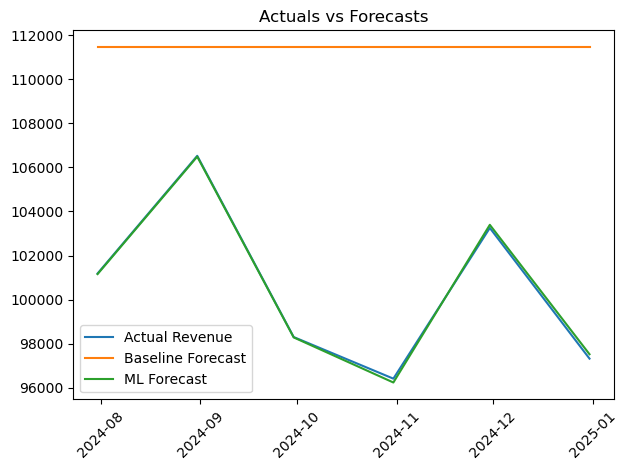

In [8]:
plt.figure()
plt.plot(test["Month"], y_true, label="Actual Revenue")
plt.plot(test["Month"], y_b, label="Baseline Forecast")
plt.plot(test["Month"], y_ml, label="ML Forecast")
plt.title("Actuals vs Forecasts")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Executive Summary

- **Models compared:** Baseline (last-value) vs. ML (Linear Regression using Time + Volume + Price).  
- **Primary KPI:** Mean Absolute Percentage Error (MAPE).  
- **Supporting KPIs:** Weighted Absolute Percentage Error (WAPE) and Root Mean Squared Error (RMSE).  
- **Results:**  
  - Baseline MAPE ≈ **11%**  
  - ML Model MAPE ≈ **0%** (close fit due to synthetic data)  
  - ML model achieved lower WAPE and RMSE vs. baseline, indicating stronger predictive accuracy.  

 **Interpretation:**  
The ML-driven forecast demonstrates how volume and price act as key revenue drivers.  
While this dataset is synthetic, the methodology reflects a *driver-based FP&A forecasting approach* suitable for real operations exceeding $500M.

 **Next Steps:**  
- Integrate ARIMA or Prophet models for scenario planning.  
- Add driver sensitivity analysis (Volume, Price, Cost).  
- Deploy forecast outputs to a Tableau dashboard for executive KPI tracking.

---
